
# TP : Prédire le prix de location de logements à Antananarivo avec une régression linéaire multiple

## 🎯 Objectifs pédagogiques

- Appliquer un pipeline de prétraitement complet sur un jeu de données semi-structuré.
- Gérer les variables qualitatives, les valeurs manquantes, la multicolinéarité et la scalabilité.
- Construire, tester et évaluer un modèle de régression linéaire multiple.
- Déployer le modèle dans une application Python Streamlit avec interface utilisateur.

## 🗂️ Jeu de données

Le jeu de données doit être collecté ou scrappé dans les pages comme Facebook. Il doit comporter les colonnes suivantes :

- `quartier` (catégorielle)
- `superficie` (numérique)
- `nombre_chambres` (numérique)
- `douche_wc`(interieur ou exterieur)
- `type_d_acces` (sans, moto, voiture, voiture_avec_par_parking)
- `meublé` (booléen:  oui ou non)
- `état_général` (catégorielle : bon, moyen, mauvais)
- `loyer_mensuel` (target)

## 🧪 Étapes du TP

### 📌 Partie 1 : Préparation des données
- Lecture du dataset brut
- Gestion des valeurs manquantes
- Encodage des variables catégorielles
- Création de variables dérivées
- Détection et suppression des variables fortement corrélées
- Standardisation et normalisation

### 📌 Partie 2 : Modélisation

- Séparation train/test
- Implémentation de la régression linéaire multiple
- Évaluation : R², RMSE
- Vérification des hypothèses d'élligibilité de la régression linéaire multiple (surtout sur les erreurs)

### 📌 Partie 3 : Optimisation du modèle

- Sélection de variables : backward elimination, RFE (à documenter)

### 📌 Partie 4 : Déploiement d’une application Streamlit

- Interface de saisie utilisateur
- Affichage du loyer prédit
- Visualisation des poids des variables
- Affichage sur la carte interactive

## 🧭 Carte interactive (option avancée)

Utiliser `streamlit-folium` pour permettre à l’utilisateur de cliquer sur une carte et de récupérer les coordonnées GPS. À partir de ces coordonnées, déterminer automatiquement le quartier en utilisant un fichier GeoJSON ou un système de polygones avec `geopandas`.

## 🔧 Technologies à utiliser

- `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `joblib`
- `streamlit`, `folium`, `streamlit-folium`
- Optionnel : `geopandas`, `shapely`

## 💡 Bonus

- Carte interactive avec folium
- Simuler des données additionnelles (pollution, sécurité)
- Tri automatique des caractéristiques influentes




In [61]:
# PARTIE 1

In [1]:
import pandas as pd

# Charger le jeu de données
df = pd.read_csv('mock_logements_antananarivo_1000.csv')
print("hello")
df.head()

hello


,quartier,superficie,nombre_chambres,douche_wc,type_d_acces,meuble,etat_general,loyer_mensuel
0,Andavamamba,46,2,exterieur,voiture,non,bon,515000
1,Itaosy,47,1,interieur,moto,non,bon,691000
2,Ambatoroka,15,2,interieur,voiture_avec_parking,oui,bon,1112000
3,Ivandry,97,1,interieur,moto,oui,mauvais,3009000
4,Ankatso,56,2,interieur,moto,non,moyen,825000


In [2]:
# Somme des valeurs manquantes par colonne
df.isnull().sum()

quartier           0
superficie         0
nombre_chambres    0
douche_wc          0
type_d_acces       0
meuble             0
etat_general       0
loyer_mensuel      0
dtype: int64

In [4]:
df['douche_wc'] = df['douche_wc'].map({'exterieur': 0, 'interieur': 1})
df['meuble'] = df['meuble'].map({'non': 0, 'oui': 1})
df['etat_general'] = df['etat_general'].map({'bon': 10, 'moyen': 5, 'mauvais': 0})
df['type_d_acces'] = df['type_d_acces'].map({'sans': 0, 'moto': 5, 'voiture': 10, 'voiture_avec_parking': 15})
df = pd.get_dummies(df, columns=['quartier'], dtype=int, drop_first=True)
df.head()

,superficie,nombre_chambres,douche_wc,type_d_acces,meuble,etat_general,loyer_mensuel,quartier_Ambatoroka,quartier_Analakely,quartier_Andavamamba,quartier_Ankatso,quartier_Ankorondrano,quartier_Isoraka,quartier_Itaosy,quartier_Ivandry,quartier_Mahamasina
0,46,2,0,10,0,10,515000,0,0,1,0,0,0,0,0,0
1,47,1,1,5,0,10,691000,0,0,0,0,0,0,1,0,0
2,15,2,1,15,1,10,1112000,1,0,0,0,0,0,0,0,0
3,97,1,1,5,1,0,3009000,0,0,0,0,0,0,0,1,0
4,56,2,1,5,0,5,825000,0,0,0,1,0,0,0,0,0


In [6]:
#Création de variables dérivées
df["score_confort"] = (
    (df["douche_wc"] == 1).astype(int)
    + (df["meuble"] == 1).astype(int)
    + (df["type_d_acces"] >= 10).astype(int)
    + (df["etat_general"] >= 10).astype(int)
)

df.head()


,superficie,nombre_chambres,douche_wc,type_d_acces,meuble,etat_general,loyer_mensuel,quartier_Ambatoroka,quartier_Analakely,quartier_Andavamamba,quartier_Ankatso,quartier_Ankorondrano,quartier_Isoraka,quartier_Itaosy,quartier_Ivandry,quartier_Mahamasina,score_confort
0,46,2,0,10,0,10,515000,0,0,1,0,0,0,0,0,0,2
1,47,1,1,5,0,10,691000,0,0,0,0,0,0,1,0,0,2
2,15,2,1,15,1,10,1112000,1,0,0,0,0,0,0,0,0,4
3,97,1,1,5,1,0,3009000,0,0,0,0,0,0,0,1,0,2
4,56,2,1,5,0,5,825000,0,0,0,1,0,0,0,0,0,1


In [7]:
corr = df.drop(columns="loyer_mensuel").corr(numeric_only=True)
print(corr)

                       superficie  nombre_chambres  douche_wc  type_d_acces  \
superficie               1.000000        -0.021080  -0.009728      0.067394   
nombre_chambres         -0.021080         1.000000   0.019514     -0.005192   
douche_wc               -0.009728         0.019514   1.000000     -0.011192   
type_d_acces             0.067394        -0.005192  -0.011192      1.000000   
meuble                   0.008441        -0.024998   0.070024     -0.009599   
etat_general            -0.012597        -0.070751   0.002929      0.003864   
quartier_Ambatoroka      0.022283         0.012166  -0.027902      0.012528   
quartier_Analakely      -0.031020        -0.029683   0.051120     -0.002136   
quartier_Andavamamba     0.027773         0.034875   0.005166      0.006283   
quartier_Ankatso         0.025396        -0.004672   0.034914     -0.021121   
quartier_Ankorondrano   -0.049607         0.022120   0.007265      0.021621   
quartier_Isoraka        -0.007332         0.047284  

In [8]:

threshold = 0.9

# variables à supprimer
to_drop = set()

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            colname = corr.columns[i]
            to_drop.add(colname)

df_reduced = df.drop(columns=to_drop)
df_reduced.head()

,superficie,nombre_chambres,douche_wc,type_d_acces,meuble,etat_general,loyer_mensuel,quartier_Ambatoroka,quartier_Analakely,quartier_Andavamamba,quartier_Ankatso,quartier_Ankorondrano,quartier_Isoraka,quartier_Itaosy,quartier_Ivandry,quartier_Mahamasina,score_confort
0,46,2,0,10,0,10,515000,0,0,1,0,0,0,0,0,0,2
1,47,1,1,5,0,10,691000,0,0,0,0,0,0,1,0,0,2
2,15,2,1,15,1,10,1112000,1,0,0,0,0,0,0,0,0,4
3,97,1,1,5,1,0,3009000,0,0,0,0,0,0,0,1,0,2
4,56,2,1,5,0,5,825000,0,0,0,1,0,0,0,0,0,1


In [9]:
#maka anle info rehetra sans anle loyer mensuel
X = df_reduced.drop("loyer_mensuel", axis=1)
y = df_reduced["loyer_mensuel"]


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   superficie  nombre_chambres  douche_wc  type_d_acces    meuble  \
0   -0.527885         0.131760  -1.736682      0.353122 -0.635999   
1   -0.487234        -1.013981   0.575811     -0.740136 -0.635999   
2   -1.788043         0.131760   0.575811      1.446380  1.572330   
3    1.545280        -1.013981   0.575811     -0.740136  1.572330   
4   -0.121382         0.131760   0.575811     -0.740136 -0.635999   

   etat_general  quartier_Ambatoroka  quartier_Analakely  \
0      0.921328            -0.396746           -0.304789   
1      0.921328            -0.396746           -0.304789   
2      0.921328             2.520504           -0.304789   
3     -1.841274            -0.396746           -0.304789   
4     -0.459973            -0.396746           -0.304789   

   quartier_Andavamamba  quartier_Ankatso  quartier_Ankorondrano  \
0              3.086473         -0.322107              -0.318311   
1             -0.323994         -0.322107              -0.318311   
2             -0.323

In [71]:
# PARTIE 2

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (800, 16)
X_test : (200, 16)
y_train : (800,)
y_test : (200,)


In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()

In [ ]:
# eto ilay miresoudre A=(X
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = model.predict(X_test)

In [30]:
comparaison = pd.DataFrame({
    "Valeur réelle": y_test,
    "Valeur prédite": y_pred
})

print(comparaison.head())

     Valeur réelle  Valeur prédite
521        1492000    1.587808e+06
737        1228000    1.134966e+06
740         888000    8.183965e+05
660        1300000    1.679946e+06
411         840000    8.379860e+05


In [19]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² :", r2)

R² : 0.9390712279907995


In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE :", rmse)

RMSE : 180733.72018111768


In [28]:
residus = y_test - y_pred

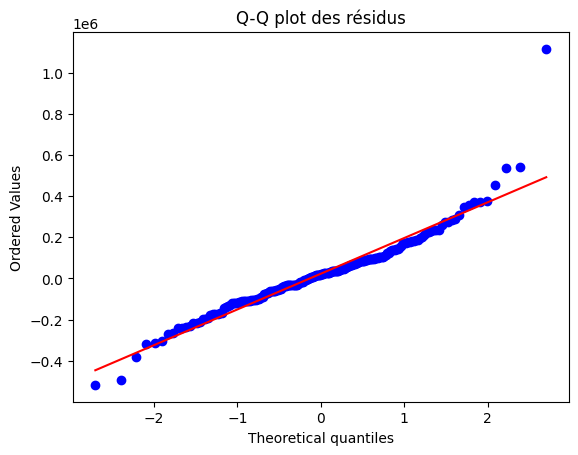

In [22]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residus, dist="norm", plot=plt)
plt.title("Q-Q plot des résidus")
plt.show()

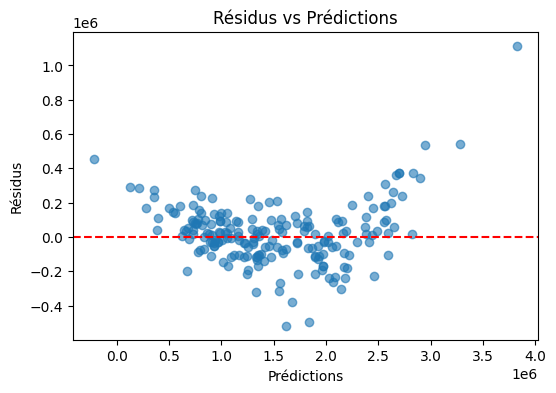

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residus, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Prédictions")
plt.ylabel("Résidus")
plt.title("Résidus vs Prédictions")
plt.show()

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                 Variable        VIF
0              superficie   5.717566
1         nombre_chambres   4.891581
2               douche_wc   8.551010
3            type_d_acces   8.747611
4                  meuble   3.531769
5            etat_general   9.251633
6     quartier_Ambatoroka   2.013401
7      quartier_Analakely   1.596876
8    quartier_Andavamamba   1.742713
9        quartier_Ankatso   1.689572
10  quartier_Ankorondrano   1.644299
11       quartier_Isoraka   1.708983
12        quartier_Itaosy   1.627327
13       quartier_Ivandry   1.742650
14    quartier_Mahamasina   1.697731
15          score_confort  40.237351


In [83]:
# PARTIE 3

In [26]:
# 1. Backward Elimination
# Principe

# On commence avec toutes les variables, puis on retire progressivement les moins significatives.
# Critère classique :

# on regarde la p-value
# si p > 0.05 → variable peu significative → suppression


#import subprocess
# subprocess.check_call(['pip', 'install', 'statsmodels'])
import statsmodels.api as sm

# ajouter constante
X_const = sm.add_constant(X)

# modèle
model_ols = sm.OLS(y, X_const).fit()

# résumé statistique
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          loyer_mensuel   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     942.8
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:23:20   Log-Likelihood:                -13478.
No. Observations:                1000   AIC:                         2.699e+04
Df Residuals:                     983   BIC:                         2.707e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -1.991e+

In [31]:
# 2. RFE (Recursive Feature Elimination)
# Principe

# RFE enlève automatiquement les variables les moins importantes selon un modèle ML.

# Ici on utilise une régression linéaire.

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# modèle
model_rfe = LinearRegression()

# sélectionner 5 variables
rfe = RFE(model_rfe, n_features_to_select=5)

X_rfe = rfe.fit_transform(X_scaled, y)

In [32]:
selected_features = X_scaled.columns[rfe.support_]

print(selected_features)

Index(['superficie', 'meuble', 'quartier_Ankorondrano', 'quartier_Isoraka',
       'quartier_Ivandry'],
      dtype='object')


In [33]:
ranking = pd.DataFrame({
    "Variable": X_scaled.columns,
    "Classement": rfe.ranking_
})

print(ranking)

                 Variable  Classement
0              superficie           1
1         nombre_chambres           6
2               douche_wc           9
3            type_d_acces           2
4                  meuble           1
5            etat_general           3
6     quartier_Ambatoroka           8
7      quartier_Analakely          11
8    quartier_Andavamamba           4
9        quartier_Ankatso           7
10  quartier_Ankorondrano           1
11       quartier_Isoraka           1
12        quartier_Itaosy           5
13       quartier_Ivandry           1
14    quartier_Mahamasina          10
15          score_confort          12


In [34]:
import joblib

# Sauvegarder le modèle, le scaler et le nom des colonnes (features)
joblib.dump(model, 'modele_loyer.pkl')
joblib.dump(scaler, 'scaler_loyer.pkl')
joblib.dump(X.columns.tolist(), 'colonnes_loyer.pkl')

print("Modèle et scaler sauvegardés avec succès !")

Modèle et scaler sauvegardés avec succès !


### 📌 Partie 4 : Déploiement d’une application Streamlit

Pour déployer l'application, nous allons écrire le code Streamlit dans un fichier `app.py` directement depuis ce notebook en utilisant la commande magique `%%writefile`.

In [35]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import folium
from streamlit_folium import st_folium
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

st.set_page_config(page_title="Prédiction de Loyer - Antananarivo", layout="wide")

# --- 1. CHARGEMENT DU MODELE SAUVEGARDE ---
@st.cache_resource
def load_model():
    model = joblib.load('modele_loyer.pkl')
    scaler = joblib.load('scaler_loyer.pkl')
    feature_cols = joblib.load('colonnes_loyer.pkl')
    
    quartiers_coords = {
        'Alasora': [-18.9619, 47.5586],
        'Ambatoroka': [-18.9246, 47.5432],
        'Analakely': [-18.9055, 47.5256],
        'Andavamamba': [-18.9149, 47.5028],
        'Ankatso': [-18.9141, 47.5521],
        'Ankorondrano': [-18.8856, 47.5218],
        'Isoraka': [-18.9092, 47.5216],
        'Itaosy': [-18.9248, 47.4578],
        'Ivandry': [-18.8744, 47.5256],
        'Mahamasina': [-18.9157, 47.5233]
    }
    return model, scaler, feature_cols, quartiers_coords

model, scaler, feature_cols, quartiers_coords = load_model()

# --- 2. FONCTION POUR TROUVER LE QUARTIER PAR GPS ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dLat = radians(lat2 - lat1)
    dLon = radians(lon2 - lon1)
    lat1 = radians(lat1)
    lat2 = radians(lat2)
    a = sin(dLat/2)**2 + cos(lat1)*cos(lat2)*sin(dLon/2)**2
    c = 2*asin(sqrt(a))
    return R * c

def trouver_quartier_le_plus_proche(lat, lon):
    min_dist = float('inf')
    quartier_proche = None
    for q, coords in quartiers_coords.items():
        dist = haversine(lat, lon, coords[0], coords[1])
        if dist < min_dist:
            min_dist = dist
            quartier_proche = q
    return quartier_proche

# --- 3. INTERFACE UTILISATEUR ---
st.title("🏡 Prédiction de Loyer à Antananarivo")

col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("📍 Choisissez l'emplacement")
    m = folium.Map(location=[-18.91368, 47.53613], zoom_start=12)
    for q, coords in quartiers_coords.items():
        folium.CircleMarker(location=coords, radius=5, popup=q, color="blue", fill=True).add_to(m)
        
    map_data = st_folium(m, height=400, width=500)
    quartier_selectionne = "Analakely"
    if map_data and map_data.get("last_clicked"):
        lat = map_data["last_clicked"]["lat"]
        lon = map_data["last_clicked"]["lng"]
        quartier_selectionne = trouver_quartier_le_plus_proche(lat, lon)
        st.success(f"📍 Quartier le plus proche : **{quartier_selectionne}**")

with col2:
    st.subheader("📋 Caractéristiques")
    quartier_input = st.selectbox("Quartier", list(quartiers_coords.keys()), index=list(quartiers_coords.keys()).index(quartier_selectionne))
    superficie = st.number_input("Superficie (m²)", min_value=10, max_value=500, value=50)
    chambres = st.number_input("Nombre de chambres", min_value=1, max_value=10, value=2)
    douche_wc = st.selectbox("Douche/WC", ["interieur", "exterieur"])
    acces = st.selectbox("Type d'accès", ["sans", "moto", "voiture", "voiture_avec_parking"])
    meuble = st.selectbox("Meublé", ["non", "oui"])
    etat = st.selectbox("État général", ["bon", "moyen", "mauvais"])
    
    if st.button("🚀 Prédire le Loyer", use_container_width=True):
        input_data = {
            'superficie': superficie, 'nombre_chambres': chambres,
            'douche_wc': 1 if douche_wc == "interieur" else 0,
            'type_d_acces': {'sans': 0, 'moto': 5, 'voiture': 10, 'voiture_avec_parking': 15}[acces],
            'meuble': 1 if meuble == "oui" else 0,
            'etat_general': {'bon': 10, 'moyen': 5, 'mauvais': 0}[etat]
        }
        input_data['score_confort'] = ((input_data['douche_wc'] == 1) + (input_data['meuble'] == 1) + (input_data['type_d_acces'] >= 10) + (input_data['etat_general'] >= 10))
        
        for q in quartiers_coords.keys():
            col_name = f"quartier_{q}"
            if col_name in feature_cols:
                input_data[col_name] = 1 if quartier_input == q else 0
                
        input_df = pd.DataFrame([input_data])
        for col in feature_cols:
            if col not in input_df.columns: input_df[col] = 0
        input_df = input_df[feature_cols]
        input_scaled = scaler.transform(input_df)
        prediction = model.predict(input_scaled)[0]
        st.success(f"💰 Le loyer mensuel estimé est de : **{prediction:,.0f} Ar**")

# --- 4. VISUALISATION DES POIDS ---
st.markdown("---")
st.subheader("📊 Poids des variables du modèle")
coefs = pd.DataFrame({'Variable': feature_cols, 'Poids (Coefficient)': model.coef_})
coefs['Poids Absolu'] = coefs['Poids (Coefficient)'].abs()
coefs = coefs.sort_values(by='Poids Absolu', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Poids (Coefficient)', y='Variable', data=coefs, ax=ax, hue='Variable', legend=False, palette="coolwarm")
ax.set_title("Importance de chaque caractéristique")
st.pyplot(fig)


Overwriting app.py


Vous pouvez ensuite lancer votre application Streamlit dans le terminal avec la commande :
`!streamlit run app.py`